# Test wave animation

The Idea is to show how the Kinematic Wave behaves. Using longer times of constant recharge so that it can be observed clearly how
fronts and tails develop.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.animation import FuncAnimation  # , FFMpegWriter
from pathlib import Path
from tools.etc import etc
from datetime import datetime

import cProfile
import pstats

nbpath ="/Users/Theo/Development/python/hydro_tools/tools/Stromingen/Kinematic_wave/notebooks"
NOTEBOOK_NAME = os.path.join(nbpath, "demo_animation.ipynb")

data_folder = os.path.join(Path(nbpath).resolve().parent, 'data')    
images_folder = os.path.join(Path(nbpath).resolve().parent, 'images')    
video_folder = os.path.join(Path(nbpath).resolve().parent, 'videos')

from tools.root_zone.src.root_zone_model  import get_deBilt_recharge # noqa
from tools.soils.src.NL_soils import Soil #noqa

from tools.Stromingen.Munsflow95.src.Munsflow import simulate_munsflow # noqa
from tools.Stromingen.Kinematic_wave.src.kinematic_wave import Kinematic_wave
from tools.Stromingen.Kinematic_wave.src.kinematic_wave import change_meteo_for_testing
from tools.Stromingen.Kinematic_wave.src.kinematic_wave import make_animation

# --- update figure settings
plt.rcParams.update({
    'font.size': 15,
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.5,
    'lines.linewidth': 2,
    'lines.markersize': 5
})


/Users/Theo/Development/python/bootstraps
/Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload

/Users/Theo/Development/python/hydro_tools/tools/.venv/lib/python3.13/site-packages
__editable__.tools-0.1.finder.__path_hook__


# Get the leakage from the root zone

First get the leakage from the root zone, which is the infiltration
at the top of the percolation zone.

We use meteo of De Bilt weather station and some values
for the capacity of the interception and rootzone reservoir.

In [2]:
# --- Simulation datespan
datespan=("1987-01-01", "2010-01-01")
datespan=("1995-01-01", "2000-01-01")


# --- Capacity of the interception and root zone reservoir [mm]
Smax_I, Smax_R, lam =0.5, 100, 0.25

# --- Evap reduction power for root zone: Ea = (S/Smax) ** lam * E
lam = 0.25

# --- Get meteo with extrac column 'RCH' which is the leakage from the root zone
meteo = get_deBilt_recharge(Smax_I=Smax_I, Smax_R=Smax_R, lam=lam, datespan=datespan)

# Simulate the flow through the unsaturated zone using the kinematic wave model

The percolation is simulated using the kinematic wave approach.

The input is a time series of daily leakage values (columns 'RCH' in meteo DataFrame.

The outcome is the flux across the (fixed) water table while a video showing
one frame per day of the moisture profiel is also generated.


[########################################] 100%
Running animation, showing progress, one dot per 100 frames, total number of frames: 300
...Done animation.
         33846764 function calls (32895382 primitive calls) in 46.442 seconds

   Ordered by: cumulative time
   List reduced from 2215 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     5433    0.245    0.000    6.388    0.001 /Users/Theo/Development/python/hydro_tools/tools/.venv/lib/python3.13/site-packages/matplotlib/axis.py:1276(_update_ticks)
    31979    2.284    0.000    5.221    0.000 /Users/Theo/Development/python/hydro_tools/tools/.venv/lib/python3.13/site-packages/matplotlib/lines.py:758(draw)
    18087    1.855    0.000    3.648    0.000 /Users/Theo/Development/python/hydro_tools/tools/.venv/lib/python3.13/site-packages/matplotlib/backends/backend_agg.py:93(draw_path)
      605    0.008    0.000    2.952    0.005 /Users/Theo/Development/python/hydro_tools/tools/.v

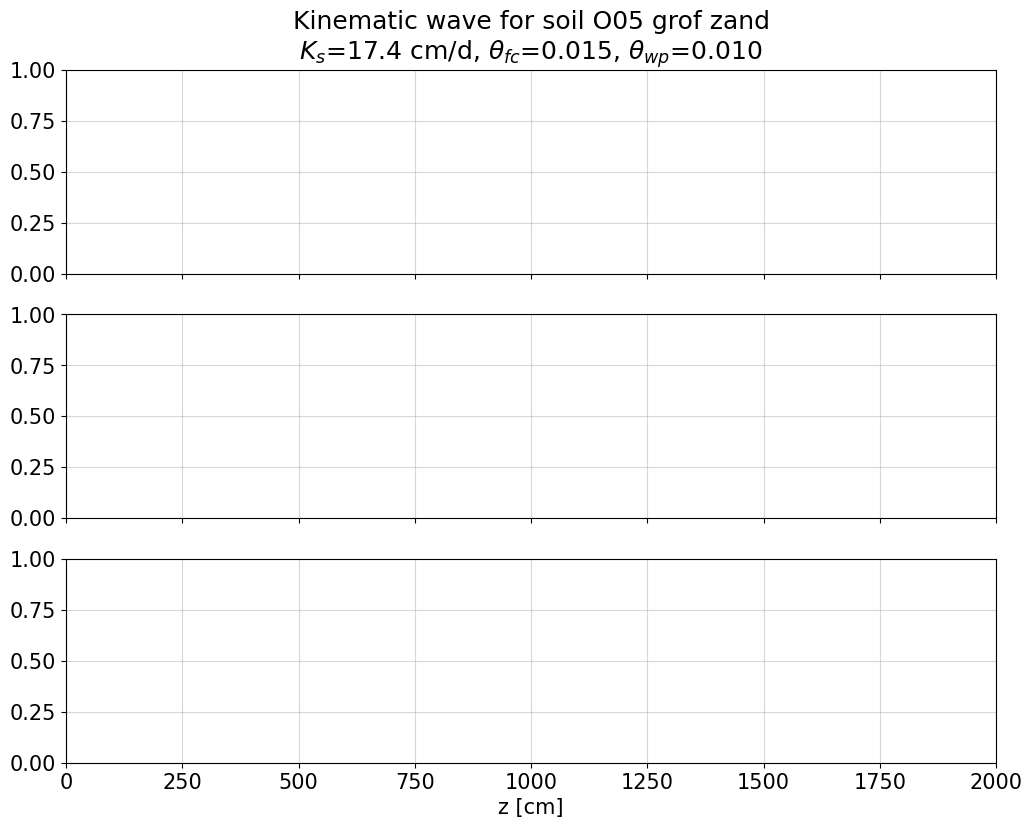

In [4]:
TEST = True
testId = 'test'
thetaL, thetaR = 0.1, 0.1
q0_test = 20 # mm/d

with cProfile.Profile() as pr: # --- Profiling the computation time
    # --- Shorten the series for convenience

    # --- If True, replace meteo DataFrame field ['RCH'] with a testing pattern
    if TEST:
        meteo = change_meteo_for_testing(meteo, N=50, m=3, q0=q0_test)[meteo.index < meteo.index[0] + np.timedelta64(300, 'D')]
        thetaL, thetaR = 0.2, 0.01
        
        # --- Continuous infiltration from day 0
        # meteo.loc[meteo.index <= meteo.index[0] + np.timedelta64(50, 'D'), 'RCH'] = 2 # mm/d

    # --- Choose a soil from the Staringreeks
    soil = Soil('O05')

    # --- Simulate and animate the kinematic wave over time
        
    # --- Initialize the Kinematic Wave profile

    # --- Root zone and gwroundwater table depth in cm
    z0, zwt = 0, 2000.

    # --- Initiate the kinematic wave object
    # --- Using soil, top elevation, water table and number of starting points
    kwave = Kinematic_wave(soil=soil, z0=z0, zwt=zwt, N=2) # z_GWT ?
    
    # --- Set initial thetaL and thetaR for starting points.
    kwave.profile['thetaL'] = thetaL  # kwave.soil.theta_fr_K(thetaL)
    kwave.profile['thetaR'] = thetaR  # kwave.soil.theta_fr_K(thetaR)

    # --- Simulate the kinematic wave
    rch_gwt = kwave.simulate(meteo)

    # --- Setup of the animation    
    fig, init_func, update_func, article_data = make_animation(kwave.profiles, soil, kwave.zwt)

    # --- Animate
    if True:
        print(f"Running animation, showing progress, one dot per 100 frames, total number of frames: {len(rch_gwt)}")
        ani = FuncAnimation(fig, update_func, frames=len(kwave.profiles), init_func=init_func,
                            blit=True, repeat=False)

        # --- Save anaimation
        dtm = datetime.now().strftime("%Y%m%d-%Hh%M")
        ani.save(
            os.path.join(images_folder,
                f"KW_{testId}-{dtm}-{soil.code}.mp4"), writer="ffmpeg", fps=20)

        plt.close(fig)

        print("Done animation.")
        
    old_title = fig.gca().get_title()
    
    fig, axs = plt.subplots(3, 1, sharex=True, sharey=True)
    fig.set_size_inches(12, 9)
    
    axs[ 0].set_title(old_title)
    axs[-1].set_xlabel('z [cm]')
    axs[-1].set_xlim(None, zwt)

    for k, ax in zip(article_data, axs):            
        # --- static reference lines (drawn once, stay forever) ---    
        ax.axhline(y=soil.theta_fc(),      color='g', lw=1, label='field capacity')
        ax.axhline(y=soil.theta_fr_K(0.1), color='m', lw=1, label='theta q=1 mm/d')
        ax.axhline(y=soil.theta_fr_K(0.2), color='r', lw=1, label='theta q=2 mm/d')

        z, theta = article_data[k]['z'], article_data[k]['theta']
        zP, thL, thR = article_data[k]['zP'], article_data[k]['thL'], article_data[k]['thR']
        ax.set_ylim(0, 0.25)
        
        ax.plot(z, theta, 'b')
        ax.plot(np.vstack((zP, zP)).flatten(), np.vstack((thL, thR)).flatten(), 'ro')

        ax.set_ylabel(r'$\theta$ [-]')            
        ax.grid(True)
        ax.legend(loc='upper right')
        
        ax.text(0.4, 0.7, f"{str(k)}"[:10], transform=ax.transAxes,
                    bbox=dict(
                        facecolor="gold",   # background color
                        edgecolor="black",  # border color
                        boxstyle="square")
                )
                    
    fig.savefig(os.path.join(images_folder, f"qwt_{soil.code}_3days"))
    
# --- Issue some statistics from the profiling
stats = pstats.Stats(pr)
stats.sort_stats("cumtime").print_stats(20)

# Some overview graphs of the simulated kinematic wave percolation

In [ ]:
# --- time spane for the overview time graphs
tspan = (np.datetime64("1990-01-01"), np.datetime64("2005-01-01"))

# --- indication of time span years to include in image file name
tspstr = str(tspan[0])[2:4] + '-' + str(tspan[1])[2:4]

# --- plot RCH and qwt
ax = etc.newfig(f"q at the water table, z0={kwave.z0} cm, zwt={kwave.zwt} cm", "time", "q mm/d")
# ax.plot(meteo.index, rch_gwt['RCH'], label='qrtz')
ax.plot(meteo.index, rch_gwt['qwt'], label='qwt, Kinematic wave')
qSeries = simulate_munsflow(meteo, soil=soil, z=zwt - z0, q_avg_cm=0.1)
ax.plot(qSeries.index, qSeries.values * 10, label='qwt_Munsflow (q_avg=0.1 cm/d)')

ax.grid(True)
ax.legend()
ax.set_xlim(tspan)
ax.figure.savefig(f"qwt_{soil.code}__{tspstr}")
ax.figure.savefig(os.path.join(images_folder, f"qwt_{soil.code}_{tspstr}"))


# --- plot integrated curve of RCH and qwt
ax = etc.newfig(f"Flux q integrated over time from rootzone and at the water table, z_rz={kwave.z0}, zwt={kwave.zwt} cm",
                "time", "integral(q) mm")
ax.plot(meteo.index, rch_gwt['RCH'].cumsum(), label='qrtz')
ax.plot(meteo.index, rch_gwt['qwt'].cumsum(), label='qwt')
ax.plot(qSeries.index, qSeries.values.cumsum() * 10, label='qwt_Munsflow')
ax.set_xlim(tspan)
ax.grid(True)
ax.legend()
ax.figure.savefig(f"qwt_{soil.code}_cumsum_{tspstr}")
ax.figure.savefig(os.path.join(images_folder,f"qwt_{soil.code}_cumsum_{tspstr}"))

# --- plot the volume under the profile as a function of time
vol = kwave.get_Vol()
ax = etc.newfig("Volume above fc [cm]", "time", "volume [cm]")
# ax.plot(rch_gwt.index, 10 * vol['V'], label="Volume")
ax.plot(meteo.index, 10 * vol['V'], label="Volume")
ax.grid(True)
ax.figure.savefig(f"vol_in_profile_{soil.code}")
ax.figure.savefig(os.path.join(images_folder, f"vol_in_profile_{soil.code}"))

print("Done")

plt.show()